
**Project introduction**
>




# SME Digital Commerce & Credit Opportunity Analysis in Pakistan

### Independent Portfolio Case Study

**Case Company:** Bazaar Technologies

**Objective:**  
Analyze digital financial behavior, payment adoption, and access to finance in Pakistan to identify SME/customer segments that may represent opportunities for digital commerce and financial services.

### Data Sources
- World Bank Global Findex 2025 – Pakistan 2024
- State Bank of Pakistan SME Financing Statistics
- Public company information

### Tools
Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

In [9]:
!pip -q install google-play-scraper vaderSentiment wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 9.1 MB/s eta 0:00:00


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

from google_play_scraper import reviews, Sort
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from wordcloud import WordCloud

print("All libraries imported successfully!")

All libraries imported successfully!


In [12]:
import os

os.makedirs("sadapay_project/data", exist_ok=True)
os.makedirs("sadapay_project/visuals", exist_ok=True)

print("Project folders created successfully!")
print()
print("📁 Main folder: sadapay_project")
print("📂 Data folder: sadapay_project/data")
print("📂 Visuals folder: sadapay_project/visuals")

Project folders created successfully!

📁 Main folder: sadapay_project
📂 Data folder: sadapay_project/data
📂 Visuals folder: sadapay_project/visuals


In [13]:
result, continuation_token = reviews(
    'com.sadapay.app',
    lang='en',
    country='pk',
    sort=Sort.NEWEST,
    count=1000
)

print("Reviews collected:", len(result))

Reviews collected: 1000


In [14]:
df = pd.DataFrame(result)

df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,7665baa0-3cd0-47cd-8390-f753dab03e63,Muadh Books,https://play-lh.googleusercontent.com/a/ACg8oc...,Very disappointing experience. I created a new...,1,0,0.1.11888,2026-09-16 04:03:34,Hello! We’d like to take a closer look into th...,2026-09-16 12:21:31,0.1.11888
1,9c1ba960-c67f-46f0-abf7-34c3208631bf,Muhammad Umar Imran,https://play-lh.googleusercontent.com/a-/ALV-U...,"They restricted my account without any issue, ...",3,0,0.1.11871,2026-09-16 00:38:20,None,NaT,0.1.11871
2,1adde3e4-ff5c-4f9f-96af-fd1fd9081c45,shahzar baig,https://play-lh.googleusercontent.com/a-/ALV-U...,There's an update literally every single day. ...,2,0,0.1.11871,2026-09-15 17:26:22,None,NaT,0.1.11871
3,680f114a-be31-45bc-8b0d-843728f664ac,Tahir Waqas,https://play-lh.googleusercontent.com/a/ACg8oc...,It's a completely useless app there's no custo...,1,0,0.1.11888,2026-09-15 15:01:50,Hello! Please contact us at quality@sadapay.pk...,2026-09-16 08:41:21,0.1.11888
4,8aa71346-5921-4aad-80f2-8aa1e0ef6ee9,Aftabtallat Faiz,https://play-lh.googleusercontent.com/a-/ALV-U...,transaction na btaey to kia kren qk ye money o...,1,0,None,2026-09-15 14:33:25,None,NaT,None


In [15]:
df = df[['reviewId', 'userName', 'score', 'content', 'at', 'thumbsUpCount']]

print("Columns selected successfully!")
print("Number of reviews:", len(df))

df.head()

Columns selected successfully!
Number of reviews: 1000


,reviewId,userName,score,content,at,thumbsUpCount
0,7665baa0-3cd0-47cd-8390-f753dab03e63,Muadh Books,1,Very disappointing experience. I created a new...,2026-09-16 04:03:34,0
1,9c1ba960-c67f-46f0-abf7-34c3208631bf,Muhammad Umar Imran,3,"They restricted my account without any issue, ...",2026-09-16 00:38:20,0
2,1adde3e4-ff5c-4f9f-96af-fd1fd9081c45,shahzar baig,2,There's an update literally every single day. ...,2026-09-15 17:26:22,0
3,680f114a-be31-45bc-8b0d-843728f664ac,Tahir Waqas,1,It's a completely useless app there's no custo...,2026-09-15 15:01:50,0
4,8aa71346-5921-4aad-80f2-8aa1e0ef6ee9,Aftabtallat Faiz,1,transaction na btaey to kia kren qk ye money o...,2026-09-15 14:33:25,0


In [16]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
reviewId         0
userName         0
score            0
content          0
at               0
thumbsUpCount    0
dtype: int64


In [17]:
df = df.dropna(subset=['content'])

df = df.drop_duplicates(subset='reviewId')

df = df.reset_index(drop=True)

print("Cleaning completed!")
print("Reviews remaining:", len(df))

Cleaning completed!
Reviews remaining: 1000


In [18]:
df['at'] = pd.to_datetime(df['at'])

df['date'] = df['at'].dt.date
df['month'] = df['at'].dt.to_period('M').astype(str)

print("Dates converted successfully!")

df[['content', 'score', 'date']].head()

Dates converted successfully!


,content,score,date
0,Very disappointing experience. I created a new...,1,2026-09-16
1,"They restricted my account without any issue, ...",3,2026-09-16
2,There's an update literally every single day. ...,2,2026-09-15
3,It's a completely useless app there's no custo...,1,2026-09-15
4,transaction na btaey to kia kren qk ye money o...,1,2026-09-15


In [19]:
print("Rating distribution:")
print(df['score'].value_counts().sort_index())

Rating distribution:
score
1    342
2     26
3     31
4     66
5    535
Name: count, dtype: int64


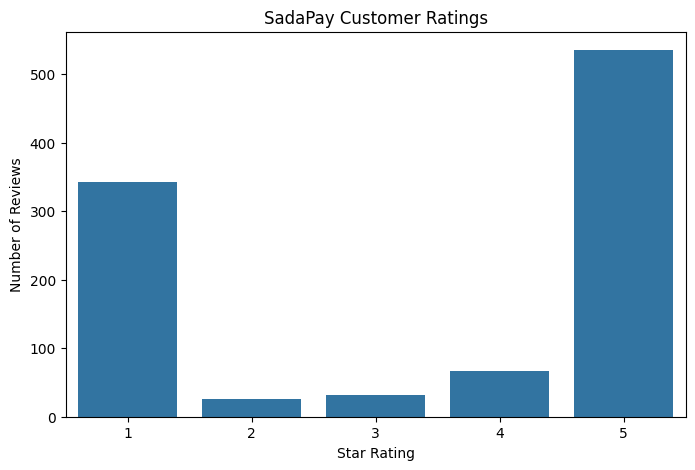

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='score',
    order=[1, 2, 3, 4, 5]
)

plt.title("SadaPay Customer Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")

plt.show()

In [22]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['clean_text'] = df['content'].apply(clean_text)

print("Text cleaning completed!")

df[['content', 'clean_text']].head()

Text cleaning completed!


,content,clean_text
0,Very disappointing experience. I created a new...,very disappointing experience i created a new ...
1,"They restricted my account without any issue, ...",they restricted my account without any issue w...
2,There's an update literally every single day. ...,there s an update literally every single day w...
3,It's a completely useless app there's no custo...,it s a completely useless app there s no custo...
4,transaction na btaey to kia kren qk ye money o...,transaction na btaey to kia kren qk ye money o...


In [23]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']

    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['clean_text'].apply(get_sentiment)

print("Sentiment analysis completed!")

df[['content', 'sentiment']].head(10)

Sentiment analysis completed!


,content,sentiment
0,Very disappointing experience. I created a new...,Negative
1,"They restricted my account without any issue, ...",Negative
2,There's an update literally every single day. ...,Negative
3,It's a completely useless app there's no custo...,Negative
4,transaction na btaey to kia kren qk ye money o...,Negative
5,Fingerprint is not working after the latest up...,Negative
6,My account deactivated due to prolonged inacti...,Positive
7,Good,Positive
8,Best assistance,Positive
9,Worst app. Kept getting me out of the account!,Negative


In [24]:
print(df['sentiment'].value_counts())

sentiment
Positive    628
Negative    255
Neutral     117
Name: count, dtype: int64


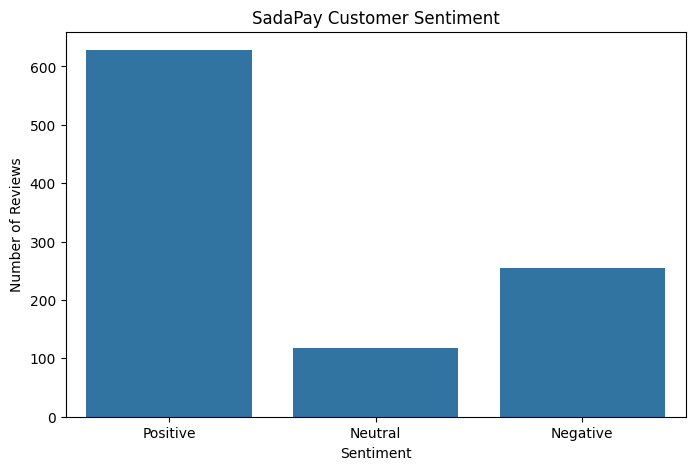

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='sentiment',
    order=['Positive', 'Neutral', 'Negative']
)

plt.title("SadaPay Customer Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [26]:
sentiment_percentage = (
    df['sentiment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Sentiment percentages:")
print(sentiment_percentage)

Sentiment percentages:
sentiment
Positive    62.8
Negative    25.5
Neutral     11.7
Name: proportion, dtype: float64


In [27]:
def categorize_review(text):

    text = text.lower()

    if any(word in text for word in [
        'support', 'customer service', 'help center', 'chat', 'response'
    ]):
        return 'Customer Support'

    elif any(word in text for word in [
        'verification', 'biometric', 'verify', 'cnic', 'identity'
    ]):
        return 'Verification'

    elif any(word in text for word in [
        'transaction', 'payment', 'refund', 'charged', 'balance'
    ]):
        return 'Transactions'

    elif any(word in text for word in [
        'transfer', 'send money', 'receive money', 'iban'
    ]):
        return 'Transfers'

    elif any(word in text for word in [
        'card', 'mastercard', 'debit card', 'virtual card'
    ]):
        return 'Cards'

    elif any(word in text for word in [
        'bug', 'error', 'crash', 'login', 'app', 'technical'
    ]):
        return 'App & Technical'

    elif any(word in text for word in [
        'fee', 'fees', 'charges', 'expensive'
    ]):
        return 'Fees'

    elif any(word in text for word in [
        'security', 'fraud', 'unauthorized', 'scam'
    ]):
        return 'Security'

    elif any(word in text for word in [
        'international', 'abroad', 'foreign', 'dollar', 'usd'
    ]):
        return 'International Payments'

    else:
        return 'Other'


df['category'] = df['clean_text'].apply(categorize_review)

print(" Customer categories created!")

df[['content', 'category']].head(10)

 Customer categories created!


,content,category
0,Very disappointing experience. I created a new...,Customer Support
1,"They restricted my account without any issue, ...",Customer Support
2,There's an update literally every single day. ...,Other
3,It's a completely useless app there's no custo...,Customer Support
4,transaction na btaey to kia kren qk ye money o...,Transactions
5,Fingerprint is not working after the latest up...,Other
6,My account deactivated due to prolonged inacti...,Other
7,Good,Other
8,Best assistance,Other
9,Worst app. Kept getting me out of the account!,App & Technical


In [28]:
negative_reviews = df[df['sentiment'] == 'Negative']

print("Total negative reviews:", len(negative_reviews))

negative_reviews[['content', 'category']].head(10)

Total negative reviews: 255


,content,category
0,Very disappointing experience. I created a new...,Customer Support
1,"They restricted my account without any issue, ...",Customer Support
2,There's an update literally every single day. ...,Other
3,It's a completely useless app there's no custo...,Customer Support
4,transaction na btaey to kia kren qk ye money o...,Transactions
5,Fingerprint is not working after the latest up...,Other
9,Worst app. Kept getting me out of the account!,App & Technical
11,Very Poor Services I am not recommending it to...,Transactions
14,time waste app.. totally zero,App & Technical
18,Very poor and disappointing service. My biomet...,Customer Support


In [29]:
negative_categories = negative_reviews['category'].value_counts()

print("Categories mentioned in negative reviews:")
print(negative_categories)

Categories mentioned in negative reviews:
category
Customer Support    70
Other               56
App & Technical     56
Transactions        30
Verification        18
Cards               15
Transfers            7
Security             3
Name: count, dtype: int64


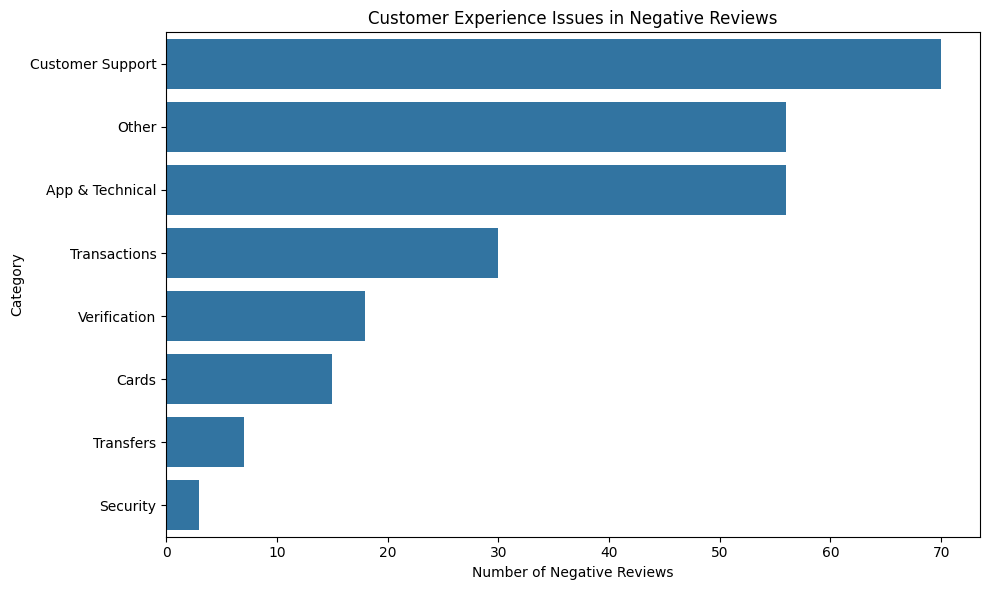

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=negative_categories.values,
    y=negative_categories.index
)

plt.title("Customer Experience Issues in Negative Reviews")
plt.xlabel("Number of Negative Reviews")
plt.ylabel("Category")

plt.tight_layout()

plt.show()

In [31]:
category_sentiment = pd.crosstab(
    df['category'],
    df['sentiment'],
    normalize='index'
) * 100

category_sentiment = category_sentiment.round(2)

category_sentiment

sentiment,Negative,Neutral,Positive
category,,,
App & Technical,22.22,11.11,66.67
Cards,44.12,8.82,47.06
Customer Support,52.24,2.24,45.52
Fees,0.00,33.33,66.67
International Payments,0.00,33.33,66.67
Other,14.85,15.65,69.50
Security,60.00,0.00,40.00
Transactions,24.19,11.29,64.52
Transfers,19.44,5.56,75.00


In [32]:
negative_percentage = (
    category_sentiment['Negative']
    .sort_values(ascending=False)
)

print(negative_percentage)

category
Security                  60.00
Verification              56.25
Customer Support          52.24
Cards                     44.12
Transactions              24.19
App & Technical           22.22
Transfers                 19.44
Other                     14.85
International Payments     0.00
Fees                       0.00
Name: Negative, dtype: float64


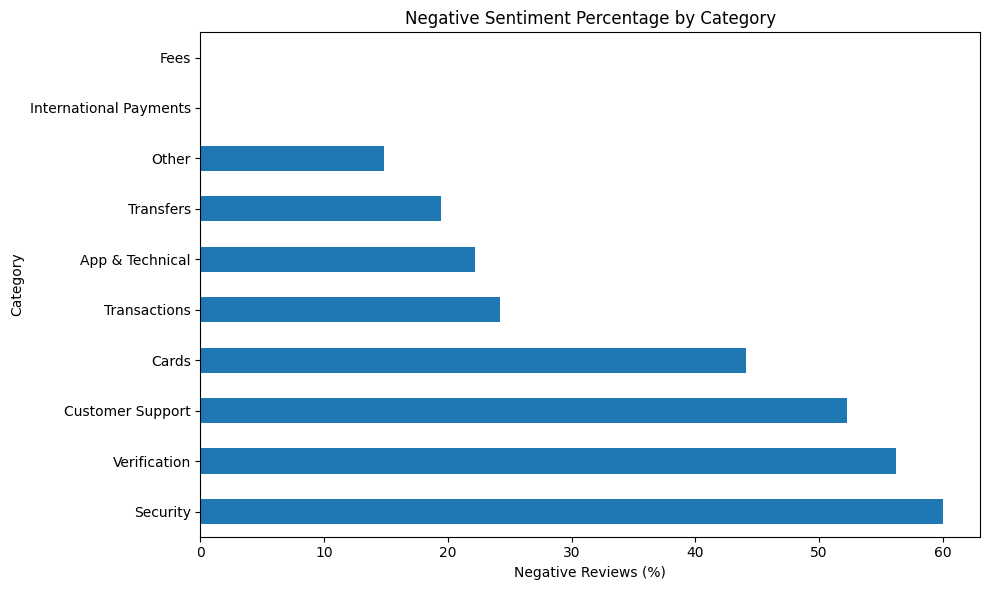

In [33]:
plt.figure(figsize=(10,6))

negative_percentage.plot(kind='barh')

plt.title("Negative Sentiment Percentage by Category")
plt.xlabel("Negative Reviews (%)")
plt.ylabel("Category")

plt.tight_layout()

plt.show()

In [34]:
monthly_sentiment = (
    df.groupby(['month', 'sentiment'])
    .size()
    .unstack(fill_value=0)
)

monthly_sentiment

sentiment,Negative,Neutral,Positive
month,,,
2026-08,199,88,499
2026-09,56,29,129


<Figure size 1200x600 with 0 Axes>

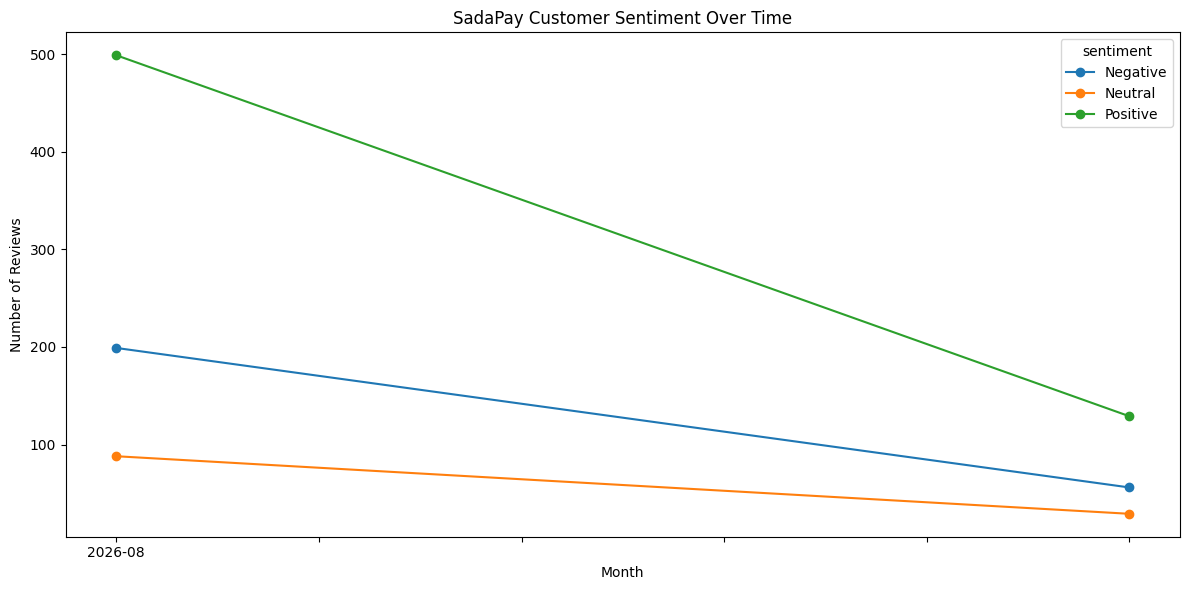

In [35]:
plt.figure(figsize=(12,6))

monthly_sentiment.plot(
    marker='o',
    figsize=(12,6)
)

plt.title("SadaPay Customer Sentiment Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")

plt.tight_layout()

plt.show()

In [37]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=100
)

tfidf_matrix = tfidf.fit_transform(df['clean_text'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (1000, 100)


In [38]:
feature_names = tfidf.get_feature_names_out()

scores = tfidf_matrix.mean(axis=0).A1

word_scores = pd.DataFrame({
    'word': feature_names,
    'score': scores
})

word_scores = word_scores.sort_values(
    'score',
    ascending=False
)

word_scores.head(20)

,word,score
3,app,0.127001
29,good,0.118389
9,best,0.059260
0,account,0.056804
71,sadapay,0.048538
53,nice,0.043066
73,service,0.042908
89,use,0.036606
27,experience,0.036481
49,money,0.031078


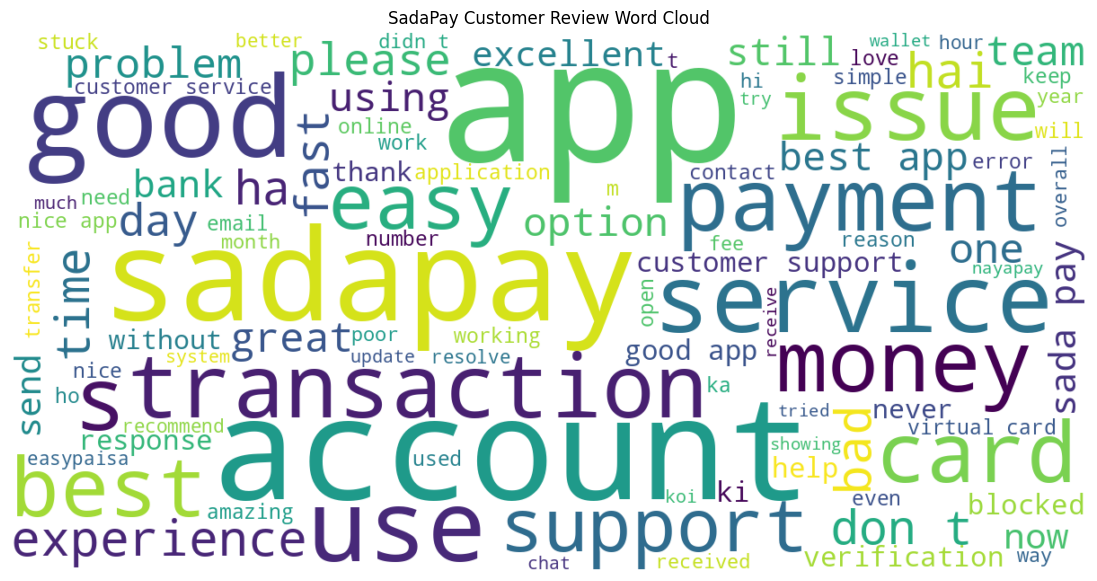

In [39]:
all_text = ' '.join(df['clean_text'])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100
).generate(all_text)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("SadaPay Customer Review Word Cloud")

plt.show()

In [40]:
topic_vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=1000,
    min_df=3
)

topic_matrix = topic_vectorizer.fit_transform(
    df['clean_text']
)

print("Topic matrix:", topic_matrix.shape)

Topic matrix: (1000, 612)


In [42]:
nmf = NMF(
    n_components=6,
    random_state=42
)

nmf_matrix = nmf.fit_transform(topic_matrix)

print("Six customer topics created!")

Six customer topics created!


In [43]:
terms = topic_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(nmf.components_):

    top_words = [
        terms[i]
        for i in topic.argsort()[-10:][::-1]
    ]

    print(f"Topic {topic_idx + 1}:")
    print(", ".join(top_words))
    print()

Topic 1:
good, experience, application, service, use, international, easy, far, work, needs

Topic 2:
best, international, use, transfer, transaction, online, better, bank, cash, apps

Topic 3:
nice, work, sada, fast, pay, time, app, services, management, hi

Topic 4:
app, amazing, banking, money, love, fast, using, transfer, easy, great

Topic 5:
excellent, service, experience, quick, fast, services, overall, recommend, transfer, easy

Topic 6:
sadapay, account, service, bad, use, experience, easy, money, support, card



In [44]:
df['topic'] = nmf_matrix.argmax(axis=1) + 1

df[['content', 'sentiment', 'category', 'topic']].head(10)

,content,sentiment,category,topic
0,Very disappointing experience. I created a new...,Negative,Customer Support,6
1,"They restricted my account without any issue, ...",Negative,Customer Support,6
2,There's an update literally every single day. ...,Negative,Other,6
3,It's a completely useless app there's no custo...,Negative,Customer Support,6
4,transaction na btaey to kia kren qk ye money o...,Negative,Transactions,6
5,Fingerprint is not working after the latest up...,Negative,Other,6
6,My account deactivated due to prolonged inacti...,Positive,Other,6
7,Good,Positive,Other,1
8,Best assistance,Positive,Other,2
9,Worst app. Kept getting me out of the account!,Negative,App & Technical,4


In [45]:
topic_counts = df['topic'].value_counts().sort_index()

print(topic_counts)

topic
1    174
2     88
3     54
4    178
5     40
6    466
Name: count, dtype: int64


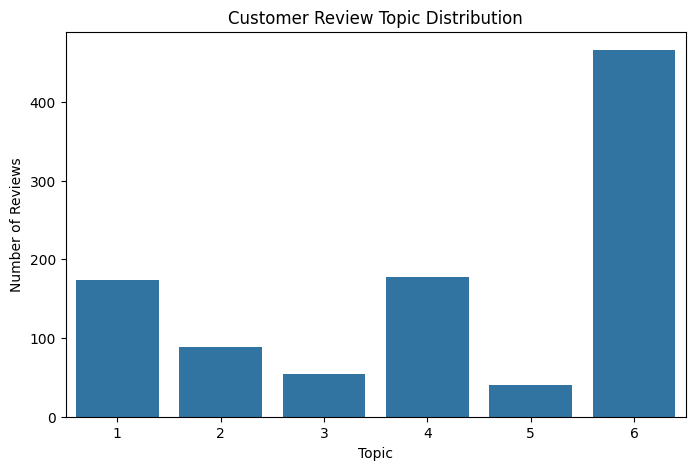

In [46]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=topic_counts.index,
    y=topic_counts.values
)

plt.title("Customer Review Topic Distribution")
plt.xlabel("Topic")
plt.ylabel("Number of Reviews")

plt.show()

In [47]:
total_reviews = len(df)

positive_pct = (df['sentiment'] == 'Positive').mean() * 100
negative_pct = (df['sentiment'] == 'Negative').mean() * 100
neutral_pct = (df['sentiment'] == 'Neutral').mean() * 100

average_rating = df['score'].mean()

print("SADAPAY CUSTOMER EXPERIENCE KPIs")

print("Total Reviews:", total_reviews)
print("Average Rating:", round(average_rating, 2), "/ 5")
print("Positive Sentiment:", round(positive_pct, 2), "%")
print("Negative Sentiment:", round(negative_pct, 2), "%")
print("Neutral Sentiment:", round(neutral_pct, 2), "%")

SADAPAY CUSTOMER EXPERIENCE KPIs
Total Reviews: 1000
Average Rating: 3.43 / 5
Positive Sentiment: 62.8 %
Negative Sentiment: 25.5 %
Neutral Sentiment: 11.7 %


In [48]:
top_negative_category = negative_categories.index[0]

print("Main category in negative reviews:")
print(top_negative_category)

print()
print("Number of negative reviews:")
print(negative_categories.iloc[0])

Main category in negative reviews:
Customer Support

Number of negative reviews:
70


In [50]:
df.to_csv(
    "sadapay_project/data/sadapay_reviews_analyzed.csv",
    index=False
)

print("Final analyzed dataset saved!")

Final analyzed dataset saved!


In [51]:
summary = pd.DataFrame({
    'Metric': [
        'Total Reviews',
        'Average Rating',
        'Positive Sentiment %',
        'Negative Sentiment %',
        'Neutral Sentiment %',
        'Main Negative Category'
    ],
    'Value': [
        total_reviews,
        round(average_rating, 2),
        round(positive_pct, 2),
        round(negative_pct, 2),
        round(neutral_pct, 2),
        top_negative_category
    ]
})

with pd.ExcelWriter(
    "sadapay_project/SadaPay_Customer_Experience_Analysis.xlsx"
) as writer:

    df.to_excel(
        writer,
        sheet_name="Reviews",
        index=False
    )

    summary.to_excel(
        writer,
        sheet_name="KPIs",
        index=False
    )

    category_sentiment.to_excel(
        writer,
        sheet_name="Category Sentiment"
    )

print("Excel report created!")

Excel report created!


In [52]:
dashboard_summary = pd.DataFrame({
    'Metric': [
        'Total Reviews',
        'Average Rating',
        'Positive Reviews',
        'Negative Reviews',
        'Neutral Reviews'
    ],
    'Value': [
        total_reviews,
        round(average_rating, 2),
        round(positive_pct, 2),
        round(negative_pct, 2),
        round(neutral_pct, 2)
    ]
})

dashboard_summary

,Metric,Value
0,Total Reviews,1000.00
1,Average Rating,3.43
2,Positive Reviews,62.80
3,Negative Reviews,25.50
4,Neutral Reviews,11.70


In [53]:
sentiment_chart = (
    df['sentiment']
    .value_counts()
    .reset_index()
)

sentiment_chart.columns = ['Sentiment', 'Reviews']

sentiment_chart

,Sentiment,Reviews
0,Positive,628
1,Negative,255
2,Neutral,117


In [54]:
category_chart = (
    df['category']
    .value_counts()
    .reset_index()
)

category_chart.columns = ['Category', 'Reviews']

category_chart

,Category,Reviews
0,Other,377
1,App & Technical,252
2,Customer Support,134
3,Transactions,124
4,Transfers,36
5,Cards,34
6,Verification,32
7,Security,5
8,International Payments,3
9,Fees,3


In [55]:
negative_chart = (
    df[df['sentiment'] == 'Negative']['category']
    .value_counts()
    .reset_index()
)

negative_chart.columns = ['Category', 'Negative Reviews']

negative_chart

,Category,Negative Reviews
0,Customer Support,70
1,Other,56
2,App & Technical,56
3,Transactions,30
4,Verification,18
5,Cards,15
6,Transfers,7
7,Security,3


In [56]:
monthly_chart = (
    df.groupby(['month', 'sentiment'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

monthly_chart

sentiment,month,Negative,Neutral,Positive
0,2026-08,199,88,499
1,2026-09,56,29,129


In [57]:
# SADAPAY CUSTOMER EXPERIENCE INTELLIGENCE DASHBOARD


!pip -q install plotly

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

# 1. PREPARE DATA


# Sentiment
sentiment_data = (
    df['sentiment']
    .value_counts()
    .reindex(['Positive', 'Neutral', 'Negative'])
    .fillna(0)
)

# Categories
category_data = (
    df['category']
    .value_counts()
    .sort_values(ascending=True)
)

# Negative categories
negative_data = (
    df[df['sentiment'] == 'Negative']['category']
    .value_counts()
    .sort_values(ascending=True)
)

# Monthly sentiment
monthly_data = (
    df.groupby(['month', 'sentiment'])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=['Positive', 'Neutral', 'Negative'], fill_value=0)
)

# Topic counts
topic_data = (
    df['topic']
    .value_counts()
    .sort_index()
)

# Top words
top_words = (
    word_scores
    .head(15)
    .sort_values('score', ascending=True)
)


#colors

BG = "#111315"
PANEL = "#181B1F"
TEXT = "#F4F1EA"
MUTED = "#A7AAA8"

MINT = "#72D6B0"
CORAL = "#F47C6C"
GOLD = "#E9C46A"
LAVENDER = "#B9A7F9"
WHITE = "#F4F1EA"

#Create Dashboard

fig = make_subplots(
    rows=4,
    cols=2,

    specs=[
        [{"type": "domain"}, {"type": "bar"}],
        [{"type": "xy", "colspan": 2}, None],
        [{"type": "bar"}, {"type": "bar"}],
        [{"type": "bar"}, {"type": "bar"}]
    ],

    row_heights=[
        0.24,
        0.25,
        0.25,
        0.26
    ],

    vertical_spacing=0.10,

    horizontal_spacing=0.10,

    subplot_titles=(
        "SENTIMENT MIX",
        "CUSTOMER EXPERIENCE CATEGORIES",
        "RECENT SENTIMENT TREND",
        "NEGATIVE SENTIMENT BY CATEGORY",
        "CUSTOMER TOPICS",
        "MOST IMPORTANT TERMS"
    )
)

#Chart 1 Sentiment Donut

fig.add_trace(
    go.Pie(
        labels=sentiment_data.index,
        values=sentiment_data.values,
        hole=0.68,

        marker=dict(
            colors=[MINT, GOLD, CORAL],
            line=dict(color=BG, width=3)
        ),

        textinfo="percent",

        textfont=dict(
            color=TEXT,
            size=14
        ),

        hovertemplate=
        "<b>%{label}</b><br>" +
        "Reviews: %{value}<br>" +
        "%{percent}<extra></extra>"
    ),

    row=1,
    col=1
)

#Chart 2 Customer Experience Categories

fig.add_trace(
    go.Bar(
        x=category_data.values,
        y=category_data.index,

        orientation="h",

        marker=dict(
            color=GOLD
        ),

        text=category_data.values,

        textposition="outside",

        textfont=dict(
            color=TEXT
        ),

        hovertemplate=
        "<b>%{y}</b><br>" +
        "Reviews: %{x}<extra></extra>"
    ),

    row=1,
    col=2
)

#Chart 3 Sentiment Trends
fig.add_trace(
    go.Scatter(
        x=monthly_data.index,
        y=monthly_data["Positive"],
        mode="lines+markers",

        name="Positive",

        line=dict(
            color=MINT,
            width=3
        ),

        marker=dict(
            size=8
        )
    ),

    row=2,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=monthly_data.index,
        y=monthly_data["Neutral"],
        mode="lines+markers",

        name="Neutral",

        line=dict(
            color=GOLD,
            width=3
        ),

        marker=dict(
            size=8
        )
    ),

    row=2,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=monthly_data.index,
        y=monthly_data["Negative"],
        mode="lines+markers",

        name="Negative",

        line=dict(
            color=CORAL,
            width=3
        ),

        marker=dict(
            size=8
        )
    ),

    row=2,
    col=1
)

#Chart 4 Negative categories

fig.add_trace(
    go.Bar(
        x=negative_data.values,
        y=negative_data.index,

        orientation="h",

        marker=dict(
            color=CORAL
        ),

        text=negative_data.values,

        textposition="outside",

        textfont=dict(
            color=TEXT
        ),

        hovertemplate=
        "<b>%{y}</b><br>" +
        "Negative reviews: %{x}<extra></extra>"
    ),

    row=3,
    col=1
)

#Chart 5 Topics

fig.add_trace(
    go.Bar(
        x=topic_data.index.astype(str),
        y=topic_data.values,

        marker=dict(
            color=LAVENDER
        ),

        text=topic_data.values,

        textposition="outside",

        textfont=dict(
            color=TEXT
        ),

        hovertemplate=
        "<b>Topic %{x}</b><br>" +
        "Reviews: %{y}<extra></extra>"
    ),

    row=3,
    col=2
)

#Chart 6: Top words

fig.add_trace(
    go.Bar(
        x=top_words["score"],
        y=top_words["word"],

        orientation="h",

        marker=dict(
            color=MINT
        ),

        hovertemplate=
        "<b>%{y}</b><br>" +
        "TF-IDF score: %{x:.3f}<extra></extra>"
    ),

    row=4,
    col=1
)

# Use final panel for rating distribution
rating_data = (
    df['score']
    .value_counts()
    .reindex([1,2,3,4,5])
    .fillna(0)
)

fig.add_trace(
    go.Bar(
        x=[str(x) + " ★" for x in rating_data.index],
        y=rating_data.values,

        marker=dict(
            color=[CORAL, CORAL, GOLD, MINT, MINT]
        ),

        text=rating_data.values,

        textposition="outside",

        textfont=dict(
            color=TEXT
        ),

        hovertemplate=
        "<b>%{x}</b><br>" +
        "Reviews: %{y}<extra></extra>"
    ),

    row=4,
    col=2
)

#4 KPI Strip

fig.add_annotation(
    x=0.02,
    y=1.18,
    xref="paper",
    yref="paper",

    text=(
        f"<b>{total_reviews:,}</b><br>"
        f"<span style='font-size:12px'>PUBLIC REVIEWS</span>"
    ),

    showarrow=False,

    align="left",

    font=dict(
        color=TEXT,
        size=23
    )
)

fig.add_annotation(
    x=0.25,
    y=1.18,
    xref="paper",
    yref="paper",

    text=(
        f"<b>{average_rating:.2f}/5</b><br>"
        f"<span style='font-size:12px'>AVERAGE RATING</span>"
    ),

    showarrow=False,

    align="left",

    font=dict(
        color=TEXT,
        size=23
    )
)

fig.add_annotation(
    x=0.49,
    y=1.18,
    xref="paper",
    yref="paper",

    text=(
        f"<b>{positive_pct:.1f}%</b><br>"
        f"<span style='font-size:12px'>POSITIVE SENTIMENT</span>"
    ),

    showarrow=False,

    align="left",

    font=dict(
        color=MINT,
        size=23
    )
)

fig.add_annotation(
    x=0.73,
    y=1.18,
    xref="paper",
    yref="paper",

    text=(
        f"<b>{negative_pct:.1f}%</b><br>"
        f"<span style='font-size:12px'>NEGATIVE SENTIMENT</span>"
    ),

    showarrow=False,

    align="left",

    font=dict(
        color=CORAL,
        size=23
    )
)

#5 Title

fig.add_annotation(
    x=0.02,
    y=1.32,

    xref="paper",
    yref="paper",

    text=(
        "<b>SADAPAY</b>  /  CUSTOMER EXPERIENCE INTELLIGENCE"
    ),

    showarrow=False,

    align="left",

    font=dict(
        color=TEXT,
        size=28
    )
)

fig.add_annotation(
    x=0.02,
    y=1.27,

    xref="paper",
    yref="paper",

    text=(
        "NLP analysis of publicly available customer reviews"
    ),

    showarrow=False,

    align="left",

    font=dict(
        color=MUTED,
        size=13
    )
)

#6 General Design
fig.update_layout(

    height=1550,

    width=1250,

    paper_bgcolor=BG,

    plot_bgcolor=PANEL,

    font=dict(
        family="Arial",
        color=TEXT
    ),

    margin=dict(
        l=70,
        r=70,
        t=240,
        b=70
    ),

    showlegend=True,

    legend=dict(
        orientation="h",
        y=0.76,
        x=0.35,
        font=dict(color=MUTED)
    ),

    hoverlabel=dict(
        bgcolor="#22262A",
        font_size=13,
        font_color=TEXT
    )
)

#7 Axis Styling

fig.update_xaxes(
    showgrid=False,
    zeroline=False,
    showline=False,
    tickfont=dict(color=MUTED)
)

fig.update_yaxes(
    showgrid=False,
    zeroline=False,
    showline=False,
    tickfont=dict(color=MUTED)
)

#8 Subtitle Styling

for annotation in fig.layout.annotations:

    if annotation.text in [
        "SENTIMENT MIX",
        "CUSTOMER EXPERIENCE CATEGORIES",
        "RECENT SENTIMENT TREND",
        "NEGATIVE SENTIMENT BY CATEGORY",
        "CUSTOMER TOPICS",
        "MOST IMPORTANT TERMS"
    ]:

        annotation.font = dict(
            color=TEXT,
            size=15
        )

#9 Display

fig.show()

#10 Save

fig.write_html(
    "sadapay_project/SadaPay_Customer_Experience_Dashboard.html"
)

print("Professional interactive dashboard created!")
print("Saved as: SadaPay_Customer_Experience_Dashboard.html")

Professional interactive dashboard created!
Saved as: SadaPay_Customer_Experience_Dashboard.html


In [81]:

# SADAPAY — INTERACTIVE CUSTOMER EXPERIENCE INTELLIGENCE
# FINAL VERSION


!pip -q install plotly

import pandas as pd
import numpy as np
import json
from pathlib import Path
from IPython.display import HTML, display

# ============================================================
# 1. PREPARE DATA
# ============================================================

data = df.copy()

# Find review text column
text_candidates = ['content', 'review', 'text', 'Review', 'Content']
text_col = next((c for c in text_candidates if c in data.columns), None)

if text_col is None:
    raise ValueError("Review text column was not found.")

# Required columns
if 'sentiment' not in data.columns:
    raise ValueError("sentiment column was not found.")

if 'category' not in data.columns:
    raise ValueError("category column was not found.")

# Clean
data[text_col] = data[text_col].fillna('').astype(str)
data['sentiment'] = data['sentiment'].fillna('Neutral').astype(str)
data['category'] = data['category'].fillna('Other').astype(str)

# Rating
if 'score' in data.columns:
    data['rating'] = pd.to_numeric(data['score'], errors='coerce')
elif 'rating' in data.columns:
    data['rating'] = pd.to_numeric(data['rating'], errors='coerce')
else:
    data['rating'] = np.nan

# Date / month
if 'date' in data.columns:
    data['date'] = pd.to_datetime(data['date'], errors='coerce')
    data['month'] = data['date'].dt.to_period('M').astype(str)
else:
    data['month'] = 'Unknown'

# Negative flag
data['is_negative'] = (
    data['sentiment'].str.lower() == 'negative'
)

# ============================================================
# 2. CREATE JSON DATA FOR HTML
# ============================================================

records = []

for _, row in data.iterrows():

    rating = None

    if pd.notna(row['rating']):
        rating = int(row['rating'])

    records.append({
        'review': row[text_col],
        'sentiment': row['sentiment'],
        'category': row['category'],
        'rating': rating,
        'month': row['month']
    })

data_json = json.dumps(
    records,
    ensure_ascii=False
)

# ============================================================
# 3. HTML DASHBOARD
# ============================================================

html = r'''
<!DOCTYPE html>

<html>

<head>

<meta charset="UTF-8">

<script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>

<style>

* {
    box-sizing: border-box;
}

body {

    margin: 0;

    background: #070A0F;

    color: #F5F8FC;

    font-family:
        Arial,
        Helvetica,
        sans-serif;
}


/* ============================================================
   MAIN DASHBOARD
   ============================================================ */

.dashboard {

    width: 100%;

    max-width: 1500px;

    margin: auto;

    padding: 28px;
}


/* ============================================================
   HEADER
   ============================================================ */

.header {

    display: flex;

    justify-content: space-between;

    align-items: center;

    gap: 25px;

    padding-bottom: 22px;

    margin-bottom: 25px;

    border-bottom:
        1px solid #1C2A3A;
}


.title {

    font-size: 30px;

    font-weight: 700;

    letter-spacing: 1px;

    line-height: 1.2;
}


.subtitle {

    color: #8FA4B8;

    margin-top: 8px;

    font-size: 14px;
}


.badge {

    border:
        1px solid #00CFFF;

    color: #00D9FF;

    padding: 10px 16px;

    border-radius: 20px;

    font-size: 11px;

    letter-spacing: .8px;

    white-space: nowrap;
}


/* ============================================================
   FILTERS
   ============================================================ */

.filters {

    display: grid;

    grid-template-columns:
        repeat(4, 1fr);

    gap: 14px;

    margin-bottom: 20px;
}


.filter-box {

    background: #0D1219;

    border:
        1px solid #1C2A3A;

    border-radius: 10px;

    padding: 15px;
}


.filter-box label {

    display: block;

    color: #8FA4B8;

    font-size: 11px;

    text-transform: uppercase;

    letter-spacing: 1px;

    margin-bottom: 8px;
}


select {

    width: 100%;

    background: #080C11;

    color: #F5F8FC;

    border:
        1px solid #294157;

    padding: 11px;

    border-radius: 7px;

    font-size: 14px;

    outline: none;
}


select:focus {

    border-color: #00D9FF;

    box-shadow:
        0 0 0 2px
        rgba(0,217,255,.12);
}


.reset {

    margin-top: 10px;

    background: transparent;

    color: #00D9FF;

    border:
        1px solid #00D9FF;

    padding: 8px 15px;

    border-radius: 6px;

    cursor: pointer;
}


.reset:hover {

    background: #00D9FF;

    color: #070A0F;
}


/* ============================================================
   KPI SECTION
   ============================================================ */

.kpis {

    display: grid;

    grid-template-columns:
        repeat(4, 1fr);

    gap: 14px;

    margin-bottom: 20px;
}


.kpi {

    background: #0D1219;

    border:
        1px solid #172536;

    border-bottom:
        2px solid #126B94;

    padding: 17px;
}


.kpi-label {

    color: #8FA4B8;

    font-size: 11px;

    text-transform: uppercase;

    letter-spacing: .7px;
}


.kpi-value {

    font-size: 28px;

    font-weight: 700;

    margin-top: 7px;

    color: #F5F8FC;
}


/* ============================================================
   CHART GRID
   ============================================================ */

.chart-grid {

    display: grid;

    grid-template-columns:
        1fr 1fr;

    gap: 16px;
}


.panel {

    background: #0D1219;

    border:
        1px solid #1C2A3A;

    border-radius: 10px;

    padding: 10px;

    overflow: hidden;
}


.panel-title {

    font-size: 15px;

    font-weight: 600;

    padding:
        10px 13px;

    color: #F5F8FC;
}


.chart {

    height: 390px;
}


/* ============================================================
   PAIN POINTS
   ============================================================ */

.pain-section {

    margin-top: 18px;
}


.info-text {

    color: #8FA4B8;

    font-size: 12px;

    padding:
        0 13px 12px;
}


.pain-table {

    width: 100%;

    border-collapse:
        collapse;
}


.pain-table th {

    color: #7890A5;

    font-size: 11px;

    text-align: left;

    text-transform: uppercase;

    padding: 12px;

    border-bottom:
        1px solid #243443;
}


.pain-table td {

    padding: 13px 12px;

    border-bottom:
        1px solid #182532;

    font-size: 13px;
}


.pain-row {

    cursor: pointer;

    transition:
        background .15s ease;
}


.pain-row:hover {

    background: #101B27;
}


.pain-row.selected {

    background: #102331;
}


.issue-name {

    color: #58D9FF;

    font-weight: 600;
}


.bar-bg {

    background: #172633;

    height: 7px;

    border-radius: 5px;

    width: 120px;
}


.bar-fill {

    height: 7px;

    border-radius: 5px;

    background:
        #00CFFF;
}


/* ============================================================
   REVIEW EXPLORER
   ============================================================ */

.reviews-section {

    margin-top: 18px;
}


.review-count {

    color: #8FA4B8;

    font-size: 12px;

    margin:
        0 13px 10px;
}


.review-list {

    max-height: 600px;

    overflow-y: auto;
}


.review {

    padding: 15px;

    border-bottom:
        1px solid #1B2A38;
}


.review:hover {

    background: #101820;
}


.review-top {

    display: flex;

    justify-content: space-between;

    align-items: center;

    gap: 10px;

    flex-wrap: wrap;
}


.review-category {

    color: #55D9FF;

    font-weight: 600;

    font-size: 13px;
}


.review-rating {

    color: #4DBBFF;

    letter-spacing: 1px;
}


.review-sentiment {

    font-size: 11px;

    padding:
        4px 9px;

    border-radius: 12px;
}


.review-sentiment.negative {

    background:
        rgba(0,168,255,.14);

    color: #4DC9FF;
}


.review-sentiment.positive {

    background:
        rgba(0,217,255,.12);

    color: #00D9FF;
}


.review-sentiment.neutral {

    background:
        rgba(77,150,200,.13);

    color: #8EC9E8;
}


.review-text {

    margin-top: 9px;

    color: #D4DEE7;

    line-height: 1.55;

    font-size: 13px;
}


/* ============================================================
   FOOTER
   ============================================================ */

.footer {

    text-align: center;

    color: #647A8D;

    font-size: 11px;

    padding: 25px 0 5px;
}


/* ============================================================
   RESPONSIVE
   ============================================================ */

@media(max-width: 900px) {

    .filters,
    .kpis,
    .chart-grid {

        grid-template-columns:
            1fr;
    }


    .header {

        display: block;
    }


    .badge {

        display: inline-block;

        margin-top: 15px;
    }


    .dashboard {

        padding: 15px;
    }

}


</style>

</head>


<body>


<div class="dashboard">


<!-- ========================================================
     HEADER
     ======================================================== -->

<div class="header">

    <div>

        <div class="title">
            SADAPAY / CUSTOMER EXPERIENCE INTELLIGENCE
        </div>

        <div class="subtitle">
            Interactive NLP analysis of publicly available customer reviews
        </div>

    </div>


    <div class="badge">
        AI + NLP CUSTOMER INTELLIGENCE
    </div>

</div>


<!-- ========================================================
     FILTERS
     ======================================================== -->

<div class="filters">


    <div class="filter-box">

        <label>Sentiment</label>

        <select id="sentimentFilter">

            <option value="All">
                All Sentiments
            </option>

            <option value="Positive">
                Positive
            </option>

            <option value="Neutral">
                Neutral
            </option>

            <option value="Negative">
                Negative
            </option>

        </select>

    </div>


    <div class="filter-box">

        <label>Customer Issue</label>

        <select id="categoryFilter">

            <option value="All">
                All Categories
            </option>

        </select>

    </div>


    <div class="filter-box">

        <label>Rating</label>

        <select id="ratingFilter">

            <option value="All">
                All Ratings
            </option>

            <option value="5">
                5 Stars
            </option>

            <option value="4">
                4 Stars
            </option>

            <option value="3">
                3 Stars
            </option>

            <option value="2">
                2 Stars
            </option>

            <option value="1">
                1 Star
            </option>

        </select>

    </div>


    <div class="filter-box">

        <label>Review Month</label>

        <select id="monthFilter">

            <option value="All">
                All Months
            </option>

        </select>


        <button
            class="reset"
            id="resetBtn"
            type="button">

            Reset Filters

        </button>

    </div>


</div>


<!-- ========================================================
     KPI
     ======================================================== -->

<div class="kpis">


    <div class="kpi">

        <div class="kpi-label">
            Reviews in View
        </div>

        <div
            class="kpi-value"
            id="totalReviews">

            0

        </div>

    </div>


    <div class="kpi">

        <div class="kpi-label">
            Average Rating
        </div>

        <div
            class="kpi-value"
            id="avgRating">

            0.00

        </div>

    </div>


    <div class="kpi">

        <div class="kpi-label">
            Positive Sentiment
        </div>

        <div
            class="kpi-value"
            id="positivePct">

            0%

        </div>

    </div>


    <div class="kpi">

        <div class="kpi-label">
            Negative Sentiment
        </div>

        <div
            class="kpi-value"
            id="negativePct">

            0%

        </div>

    </div>


</div>


<!-- ========================================================
     CHARTS
     ======================================================== -->

<div class="chart-grid">


    <div class="panel">

        <div class="panel-title">
            Sentiment Distribution
        </div>

        <div
            id="sentimentChart"
            class="chart">
        </div>

    </div>


    <div class="panel">

        <div class="panel-title">
            Customer Experience Categories
        </div>

        <div
            id="categoryChart"
            class="chart">
        </div>

    </div>


    <div class="panel">

        <div class="panel-title">
            Negative Sentiment by Category
        </div>

        <div
            id="negativeChart"
            class="chart">
        </div>

    </div>


    <div class="panel">

        <div class="panel-title">
            Rating Distribution
        </div>

        <div
            id="ratingChart"
            class="chart">
        </div>

    </div>


</div>


<!-- ========================================================
     TOP PAIN POINTS
     ======================================================== -->

<div class="panel pain-section">

    <div class="panel-title">
        TOP CUSTOMER PAIN POINTS
    </div>

    <div class="info-text">
        Click an issue to filter the review explorer to
        negative reviews for that issue.
    </div>


    <table class="pain-table">

        <thead>

            <tr>

                <th>
                    Issue
                </th>

                <th>
                    Reviews
                </th>

                <th>
                    Negative Reviews
                </th>

                <th>
                    Negative %
                </th>

                <th>
                    Intensity
                </th>

            </tr>

        </thead>


        <tbody id="painTable">

        </tbody>

    </table>

</div>


<!-- ========================================================
     REVIEW EXPLORER
     ======================================================== -->

<div class="panel reviews-section">

    <div class="panel-title">
        CUSTOMER REVIEW EXPLORER
    </div>


    <div
        class="review-count"
        id="reviewCount">

        Showing reviews

    </div>


    <div
        class="review-list"
        id="reviewList">

    </div>

</div>


<div class="footer">

    SadaPay Customer Experience Intelligence
    · NLP Portfolio Analysis
    · Public Review Data

</div>


</div>


<script>


// ============================================================
// DATA
// ============================================================

const reviews = __DATA__;

let currentData = reviews.slice();


// ============================================================
// FILTER ELEMENTS
// ============================================================

const sentimentFilter =
    document.getElementById(
        "sentimentFilter"
    );

const categoryFilter =
    document.getElementById(
        "categoryFilter"
    );

const ratingFilter =
    document.getElementById(
        "ratingFilter"
    );

const monthFilter =
    document.getElementById(
        "monthFilter"
    );


// ============================================================
// POPULATE CATEGORY FILTER
// ============================================================

const categories = [
    ...new Set(
        reviews.map(
            r => r.category
        )
    )
]
.sort();


categories.forEach(category => {

    const option =
        document.createElement(
            "option"
        );

    option.value = category;

    option.textContent = category;

    categoryFilter.appendChild(
        option
    );

});


// ============================================================
// POPULATE MONTH FILTER
// ============================================================

const months = [
    ...new Set(
        reviews.map(
            r => r.month
        )
    )
]
.filter(
    x => x !== "Unknown"
)
.sort();


months.forEach(month => {

    const option =
        document.createElement(
            "option"
        );

    option.value = month;

    option.textContent = month;

    monthFilter.appendChild(
        option
    );

});


// ============================================================
// GET FILTERED DATA
// ============================================================

function getFilteredData() {

    let result =
        reviews.slice();


    if (
        sentimentFilter.value !== "All"
    ) {

        result =
            result.filter(
                r =>
                    r.sentiment.toLowerCase()
                    ===
                    sentimentFilter.value.toLowerCase()
            );

    }


    if (
        categoryFilter.value !== "All"
    ) {

        result =
            result.filter(
                r =>
                    r.category
                    ===
                    categoryFilter.value
            );

    }


    if (
        ratingFilter.value !== "All"
    ) {

        result =
            result.filter(
                r =>
                    r.rating
                    ===
                    Number(
                        ratingFilter.value
                    )
            );

    }


    if (
        monthFilter.value !== "All"
    ) {

        result =
            result.filter(
                r =>
                    r.month
                    ===
                    monthFilter.value
            );

    }


    return result;

}


// ============================================================
// PLOTLY BASE LAYOUT
// ============================================================

const baseLayout = {

    paper_bgcolor:
        "#0D1219",

    plot_bgcolor:
        "#0D1219",

    font: {

        color:
            "#F5F8FC",

        family:
            "Arial"

    },

    margin: {

        l: 60,

        r: 25,

        t: 20,

        b: 55

    },

    xaxis: {

        gridcolor:
            "#1D2B38",

        zerolinecolor:
            "#1D2B38",

        color:
            "#8FA4B8"

    },

    yaxis: {

        gridcolor:
            "#1D2B38",

        zerolinecolor:
            "#1D2B38",

        color:
            "#DCE7F0"

    }

};


// ============================================================
// UPDATE DASHBOARD
// ============================================================

function updateDashboard() {


    currentData =
        getFilteredData();


    // --------------------------------------------------------
    // KPIs
    // --------------------------------------------------------

    const total =
        currentData.length;


    document.getElementById(
        "totalReviews"
    ).textContent =
        total.toLocaleString();


    const ratings =
        currentData
        .map(
            r => r.rating
        )
        .filter(
            r =>
                r !== null &&
                !isNaN(r)
        );


    const avg =
        ratings.length
        ?
        ratings.reduce(
            (a,b) => a + b,
            0
        ) / ratings.length
        :
        0;


    document.getElementById(
        "avgRating"
    ).textContent =
        avg.toFixed(2);


    const positive =
        currentData.filter(
            r =>
                r.sentiment.toLowerCase()
                === "positive"
        ).length;


    const negative =
        currentData.filter(
            r =>
                r.sentiment.toLowerCase()
                === "negative"
        ).length;


    document.getElementById(
        "positivePct"
    ).textContent =
        total
        ?
        (
            positive /
            total *
            100
        ).toFixed(1) + "%"
        :
        "0%";


    document.getElementById(
        "negativePct"
    ).textContent =
        total
        ?
        (
            negative /
            total *
            100
        ).toFixed(1) + "%"
        :
        "0%";


    // --------------------------------------------------------
    // SENTIMENT DONUT
    // --------------------------------------------------------

    const sentiments = [
        "Positive",
        "Neutral",
        "Negative"
    ];


    const sentimentCounts =
        sentiments.map(
            s =>
                currentData.filter(
                    r =>
                        r.sentiment.toLowerCase()
                        ===
                        s.toLowerCase()
                ).length
        );


    Plotly.react(

        "sentimentChart",

        [{

            labels:
                sentiments,

            values:
                sentimentCounts,

            type:
                "pie",

            hole:
                0.64,

            textinfo:
                "label+percent",

            textfont: {

                color:
                    "#F5F8FC",

                size:
                    12

            },

            marker: {

                colors: [

                    "#00D9FF",

                    "#4D9FC7",

                    "#008CFF"

                ],

                line: {

                    color:
                        "#0D1219",

                    width:
                        2

                }

            }

        }],

        {

            ...baseLayout,

            showlegend:
                false

        },

        {

            responsive:
                true

        }

    );


    // --------------------------------------------------------
    // CATEGORY CHART
    // --------------------------------------------------------

    const categoryMap = {};


    currentData.forEach(r => {

        categoryMap[r.category] =
            (
                categoryMap[r.category]
                ||
                0
            ) + 1;

    });


    const categoryEntries =
        Object.entries(
            categoryMap
        )
        .sort(
            (a,b) =>
                b[1] - a[1]
        )
        .slice(
            0,
            10
        );


    Plotly.react(

        "categoryChart",

        [{

            x:
                categoryEntries
                .map(
                    x => x[1]
                )
                .reverse(),

            y:
                categoryEntries
                .map(
                    x => x[0]
                )
                .reverse(),

            type:
                "bar",

            orientation:
                "h",

            marker: {

                color:
                    "#167FC1"

            },

            hovertemplate:
                "%{y}<br>Reviews: %{x}<extra></extra>"

        }],

        {

            ...baseLayout,

            showlegend:
                false,

            margin: {

                l:
                    135,

                r:
                    20,

                t:
                    20,

                b:
                    50

            }

        },

        {

            responsive:
                true

        }

    );


    // --------------------------------------------------------
    // NEGATIVE CATEGORY
    // --------------------------------------------------------

    const negativeMap = {};


    currentData.forEach(r => {

        if (
            r.sentiment.toLowerCase()
            === "negative"
        ) {

            negativeMap[r.category] =
                (
                    negativeMap[r.category]
                    ||
                    0
                ) + 1;

        }

    });


    const negativeEntries =
        Object.entries(
            negativeMap
        )
        .sort(
            (a,b) =>
                b[1] - a[1]
        )
        .slice(
            0,
            10
        );


    Plotly.react(

        "negativeChart",

        [{

            x:
                negativeEntries
                .map(
                    x => x[1]
                )
                .reverse(),

            y:
                negativeEntries
                .map(
                    x => x[0]
                )
                .reverse(),

            type:
                "bar",

            orientation:
                "h",

            marker: {

                color:
                    "#00B8F0"

            },

            hovertemplate:
                "%{y}<br>Negative reviews: %{x}<extra></extra>"

        }],

        {

            ...baseLayout,

            showlegend:
                false,

            margin: {

                l:
                    135,

                r:
                    20,

                t:
                    20,

                b:
                    50

            }

        },

        {

            responsive:
                true

        }

    );


    // --------------------------------------------------------
    // RATING DISTRIBUTION
    // --------------------------------------------------------

    const ratingCounts =
        [1,2,3,4,5].map(
            r =>
                currentData.filter(
                    x =>
                        x.rating === r
                ).length
        );


    Plotly.react(

        "ratingChart",

        [{

            x: [

                "1 Star",

                "2 Stars",

                "3 Stars",

                "4 Stars",

                "5 Stars"

            ],

            y:
                ratingCounts,

            type:
                "bar",

            marker: {

                color:
                    "#2D9CDB"

            },

            hovertemplate:
                "%{x}<br>Reviews: %{y}<extra></extra>"

        }],

        {

            ...baseLayout,

            showlegend:
                false

        },

        {

            responsive:
                true

        }

    );


    // --------------------------------------------------------
    // PAIN POINTS
    // --------------------------------------------------------

    updatePainPoints();


    // --------------------------------------------------------
    // REVIEWS
    // --------------------------------------------------------

    updateReviews();

}


// ============================================================
// PAIN POINT TABLE
// ============================================================

function updatePainPoints() {


    const table =
        document.getElementById(
            "painTable"
        );


    table.innerHTML = "";


    const map = {};


    currentData.forEach(r => {

        if (
            !map[r.category]
        ) {

            map[r.category] = {

                total:
                    0,

                negative:
                    0

            };

        }


        map[r.category].total++;


        if (
            r.sentiment.toLowerCase()
            === "negative"
        ) {

            map[r.category].negative++;

        }

    });


    const rows =
        Object.entries(
            map
        )
        .map(
            ([category, value]) => ({

                category:
                    category,

                total:
                    value.total,

                negative:
                    value.negative,

                pct:
                    value.total
                    ?
                    (
                        value.negative /
                        value.total *
                        100
                    )
                    :
                    0

            })
        )
        .sort(
            (a,b) =>
                b.negative -
                a.negative
        )
        .slice(
            0,
            8
        );


    rows.forEach(row => {


        const tr =
            document.createElement(
                "tr"
            );


        tr.className =
            "pain-row";


        tr.innerHTML = `

            <td>
                <span class="issue-name">
                    ${escapeHTML(row.category)}
                </span>
            </td>

            <td>
                ${row.total}
            </td>

            <td>
                ${row.negative}
            </td>

            <td>
                ${row.pct.toFixed(1)}%
            </td>

            <td>

                <div class="bar-bg">

                    <div
                        class="bar-fill"
                        style="width:${Math.min(row.pct,100)}%">
                    </div>

                </div>

            </td>

        `;


        tr.addEventListener(
            "click",
            () => {

                categoryFilter.value =
                    row.category;

                sentimentFilter.value =
                    "Negative";

                updateDashboard();

                document
                    .querySelector(
                        ".reviews-section"
                    )
                    .scrollIntoView({

                        behavior:
                            "smooth"

                    });

            }
        );


        table.appendChild(
            tr
        );

    });

}


// ============================================================
// REVIEW EXPLORER
// ============================================================

function updateReviews() {


    const container =
        document.getElementById(
            "reviewList"
        );


    const count =
        document.getElementById(
            "reviewCount"
        );


    count.textContent =
        `Showing ${currentData.length.toLocaleString()} customer reviews`;


    container.innerHTML = "";


    // Negative reviews first
    // Then positive / neutral

    const sorted =
        currentData
        .slice()
        .sort(
            (a,b) => {

                const an =
                    a.sentiment.toLowerCase()
                    === "negative";

                const bn =
                    b.sentiment.toLowerCase()
                    === "negative";

                return (
                    Number(bn)
                    -
                    Number(an)
                );

            }
        )
        .slice(
            0,
            150
        );


    sorted.forEach(r => {


        const div =
            document.createElement(
                "div"
            );


        div.className =
            "review";


        const sentimentClass =
            r.sentiment.toLowerCase();


        let ratingStars = "";


        if (
            r.rating !== null
        ) {

            ratingStars =
                "★".repeat(
                    r.rating
                );

        }


        div.innerHTML = `

            <div class="review-top">

                <span class="review-category">

                    ${escapeHTML(
                        r.category
                    )}

                </span>


                <span class="review-rating">

                    ${ratingStars}

                </span>


                <span
                    class="review-sentiment ${sentimentClass}">

                    ${escapeHTML(
                        r.sentiment
                    )}

                </span>

            </div>


            <div class="review-text">

                ${escapeHTML(
                    r.review
                )}

            </div>

        `;


        container.appendChild(
            div
        );

    });

}


// ============================================================
// SECURITY / HTML ESCAPE
// ============================================================

function escapeHTML(text) {

    return String(text)

        .replace(
            /&/g,
            "&amp;"
        )

        .replace(
            /</g,
            "&lt;"
        )

        .replace(
            />/g,
            "&gt;"
        )

        .replace(
            /"/g,
            "&quot;"
        )

        .replace(
            /'/g,
            "&#039;"
        );

}


// ============================================================
// FILTER EVENTS
// ============================================================

sentimentFilter.addEventListener(
    "change",
    updateDashboard
);


categoryFilter.addEventListener(
    "change",
    updateDashboard
);


ratingFilter.addEventListener(
    "change",
    updateDashboard
);


monthFilter.addEventListener(
    "change",
    updateDashboard
);


// ============================================================
// RESET
// ============================================================

document
    .getElementById(
        "resetBtn"
    )
    .addEventListener(
        "click",
        () => {

            sentimentFilter.value =
                "All";

            categoryFilter.value =
                "All";

            ratingFilter.value =
                "All";

            monthFilter.value =
                "All";

            updateDashboard();

        }
    );


// ============================================================
// START
// ============================================================

updateDashboard();


</script>

</body>

</html>
'''

# ============================================================
# 4. INSERT DATA
# ============================================================

html = html.replace(
    "__DATA__",
    data_json
)

# ============================================================
# 5. SAVE FINAL HTML
# ============================================================

output_dir = Path(
    "/content/sadapay_project"
)

output_dir.mkdir(
    exist_ok=True
)


dashboard_path = (
    output_dir /
    "SadaPay_Interactive_Customer_Intelligence.html"
)


dashboard_path.write_text(
    html,
    encoding="utf-8"
)


print("==============================================")
print(" FINAL DASHBOARD CREATED")
print("==============================================")
print()
print(" Theme: Black + Blue/Cyan")
print("Interactive filters: YES")
print("Customer pain points: YES")
print("Clickable pain points: YES")
print("Review explorer: YES")
print("Interactive charts: YES")
print()
print("📁 Saved at:")
print(dashboard_path)
print()
print("Next: download this HTML and open it in Chrome.")

 FINAL DASHBOARD CREATED

 Theme: Black + Blue/Cyan
Interactive filters: YES
Customer pain points: YES
Clickable pain points: YES
Review explorer: YES
Interactive charts: YES

📁 Saved at:
/content/sadapay_project/SadaPay_Interactive_Customer_Intelligence.html

Next: download this HTML and open it in Chrome.


In [80]:
from google.colab import files

files.download(
    "/content/sadapay_project/SadaPay_Interactive_Customer_Intelligence.html"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# FINAL PROFESSIONAL TOUCHES
# ============================================================

from pathlib import Path

dashboard_path = Path(
    "/content/sadapay_project/SadaPay_Interactive_Customer_Intelligence.html"
)

html = dashboard_path.read_text(encoding="utf-8")


# ============================================================
# 1. PROFESSIONAL CSS
# ============================================================

professional_css = r"""
<style>

/* ==========================================================
   PROFESSIONAL TOUCHES
   ========================================================== */

.insight-section,
.methodology-section {

    margin-top: 18px;

}


.insight-grid {

    display: grid;

    grid-template-columns:
        repeat(3, 1fr);

    gap: 14px;

}


.insight-card {

    background: #0D1219;

    border: 1px solid #1C2A3A;

    border-left: 3px solid #00CFFF;

    padding: 18px;

    border-radius: 9px;

}


.insight-card h3 {

    margin: 0 0 8px 0;

    color: #58D9FF;

    font-size: 13px;

    letter-spacing: .5px;

}


.insight-card p {

    margin: 0;

    color: #C8D4DF;

    font-size: 13px;

    line-height: 1.55;

}


.section-description {

    color: #8FA4B8;

    font-size: 12px;

    line-height: 1.6;

    padding:
        0 13px 14px;

}


.methodology-grid {

    display: grid;

    grid-template-columns:
        repeat(4, 1fr);

    gap: 12px;

    padding: 0 13px 15px;

}


.method-box {

    background: #080C11;

    border: 1px solid #172839;

    padding: 14px;

    border-radius: 8px;

}


.method-label {

    color: #6F879C;

    font-size: 10px;

    text-transform: uppercase;

    letter-spacing: .8px;

    margin-bottom: 6px;

}


.method-value {

    color: #EAF4FC;

    font-size: 13px;

    line-height: 1.45;

}


.limitations {

    margin:
        0 13px 15px;

    padding: 12px 14px;

    background: #0B141D;

    border-left: 3px solid #167FC1;

    color: #9FB2C2;

    font-size: 11px;

    line-height: 1.6;

}


.dashboard-guide {

    margin-top: 10px;

    color: #6F879C;

    font-size: 11px;

}


@media(max-width: 900px) {

    .insight-grid,
    .methodology-grid {

        grid-template-columns:
            1fr;

    }

}

</style>
"""


# Add CSS before </head>
html = html.replace(
    "</head>",
    professional_css + "\n</head>"
)


# ============================================================
# 2. EXECUTIVE INSIGHTS SECTION
# ============================================================

insights_html = r"""
<!-- ========================================================
     EXECUTIVE INSIGHTS
     ======================================================== -->

<div class="panel insight-section">

    <div class="panel-title">
        EXECUTIVE INSIGHTS
    </div>

    <div class="section-description">
        A concise interpretation of the customer experience
        signals identified in the analyzed review sample.
    </div>


    <div class="insight-grid">


        <div class="insight-card">

            <h3>
                CUSTOMER SENTIMENT
            </h3>

            <p>
                Most reviews in the analyzed sample were classified
                as positive, while a meaningful share showed negative
                sentiment. This indicates both positive product
                experiences and identifiable areas for improvement.
            </p>

        </div>


        <div class="insight-card">

            <h3>
                CUSTOMER PAIN POINTS
            </h3>

            <p>
                The pain-point analysis highlights which customer
                experience categories generate the largest number
                of negative reviews, helping prioritize areas for
                deeper investigation.
            </p>

        </div>


        <div class="insight-card">

            <h3>
                ACTIONABLE INTELLIGENCE
            </h3>

            <p>
                Combining sentiment, issue category, rating and
                review text creates a structured view of customer
                experience that can support product and service
                improvement decisions.
            </p>

        </div>


    </div>

</div>
"""


# Insert before pain points
html = html.replace(
    '<!-- ========================================================\n     TOP PAIN POINTS',
    insights_html +
    '\n<!-- ========================================================\n     TOP PAIN POINTS'
)


# ============================================================
# 3. METHODOLOGY SECTION
# ============================================================

methodology_html = r"""
<!-- ========================================================
     METHODOLOGY & DATA
     ======================================================== -->

<div class="panel methodology-section">

    <div class="panel-title">
        METHODOLOGY & DATA
    </div>

    <div class="section-description">

        This dashboard applies natural language processing and
        exploratory analysis to publicly available customer reviews.
        Use the filters above to investigate specific customer
        segments and issues.

    </div>


    <div class="methodology-grid">


        <div class="method-box">

            <div class="method-label">
                Data Source
            </div>

            <div class="method-value">
                Google Play public customer reviews
            </div>

        </div>


        <div class="method-box">

            <div class="method-label">
                Sample
            </div>

            <div class="method-value">
                1,000 recent English-language reviews
            </div>

        </div>


        <div class="method-box">

            <div class="method-label">
                NLP Methods
            </div>

            <div class="method-value">
                Text cleaning, sentiment analysis,
                TF-IDF and topic analysis
            </div>

        </div>


        <div class="method-box">

            <div class="method-label">
                Analysis
            </div>

            <div class="method-value">
                Sentiment, ratings, issue categories,
                pain points and review exploration
            </div>

        </div>


    </div>


    <div class="limitations">

        <strong>Data limitation:</strong>
        These findings describe the analyzed public review sample
        and should not be interpreted as representative of all
        SadaPay customers. Online reviews may contain selection
        and reporting bias.

    </div>


</div>
"""


# Insert before review explorer
html = html.replace(
    '<!-- ========================================================\n     REVIEW EXPLORER',
    methodology_html +
    '\n<!-- ========================================================\n     REVIEW EXPLORER'
)


# ============================================================
# 4. ADD SMALL GUIDE UNDER FILTERS
# ============================================================

guide_html = r"""
<div class="dashboard-guide">
    Tip: Use the filters to isolate specific customer experiences.
    Click a pain-point row to automatically explore related
    negative reviews.
</div>
"""

html = html.replace(
    '</div>\n\n\n<!-- ========================================================\n     KPI',
    '</div>\n' + guide_html +
    '\n\n<!-- ========================================================\n     KPI',
    1
)


# ============================================================
# 5. IMPROVE FOOTER
# ============================================================

old_footer = r"""
<div class="footer">

    SadaPay Customer Experience Intelligence
    · NLP Portfolio Analysis
    · Public Review Data

</div>
"""

new_footer = r"""
<div class="footer">

    SadaPay Customer Experience Intelligence
    · AI + NLP Portfolio Project
    · Public Review Data
    · 1,000-Review Sample

</div>
"""

html = html.replace(
    old_footer,
    new_footer
)


# ============================================================
# 6. SAVE FINAL VERSION
# ============================================================

dashboard_path.write_text(
    html,
    encoding="utf-8"
)

print("==============================================")
print(" FINAL PROFESSIONAL DASHBOARD UPDATED")
print("==============================================")
print()
print("Added:")
print("✓ Executive Insights")
print("✓ Methodology & Data section")
print("✓ Data limitation statement")
print("✓ Professional project branding")
print("✓ Dashboard usage guide")
print("✓ Cleaner portfolio presentation")
print()
print("File:")
print(dashboard_path)

In [82]:
from google.colab import files

files.download(
    "/content/sadapay_project/SadaPay_Interactive_Customer_Intelligence.html"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>